### profiling experiments

In [7]:
import cProfile as cp
import functions_regular as fnr
import functions_subtrees as fns
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import importlib
import pstats
import test
from pstats import SortKey
importlib.reload(fnr)
importlib.reload(fns)
G = nx.fast_gnp_random_graph(10, 0.4, seed=12)
H = nx.fast_gnp_random_graph(5, 0.7, seed=14)

## REGULAR ALGORITHM

In [ ]:
G = nx.fast_gnp_random_graph(40, 0.4, seed=12)
H = nx.fast_gnp_random_graph(10, 0.7, seed=14)
cp.run('fn.findSubgraphInstances(H, G, True)', 'profiling_tests/G_40_H_10')
p = pstats.Stats('profiling_tests/G_40_H_10')
p.strip_dirs().sort_stats('cumtime').print_stats()

In [ ]:
G = nx.fast_gnp_random_graph(40, 0.4, seed=13)
H = nx.fast_gnp_random_graph(15, 0.7, seed=15)
cp.run('fn.findSubgraphInstances(H, G, True)', 'profiling_tests/G_40_H_15')
p = pstats.Stats('profiling_tests/G_40_H_15')
p.strip_dirs().sort_stats('cumtime').print_stats()

## \#SUBTREE ISOMORPHISM

In [ ]:
T = nx.full_rary_tree(5, 5)
S = nx.full_rary_tree(10, 30)

cp.run('fnr.countRootedSubtrees(T, 0, S, 0)', '#subtrees_5_10_120_500')
p = pstats.Stats('#subtrees_5_10_120_500')
p.strip_dirs().sort_stats('cumtime').print_stats()

## REGULAR VS REGULAR + SUBTREE ISO 

#### QUERY GRAPH H

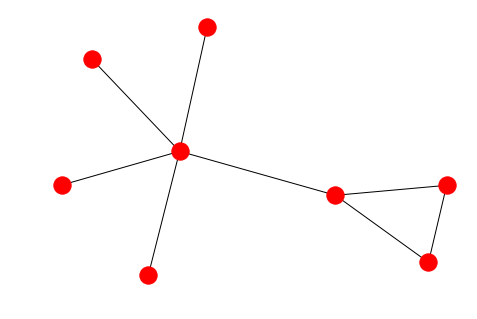

In [45]:
H = parseStringToGraph('[[0,1], [1,2], [2,0], [4,2], [3,4], [5,4], [6,4], [7,4]]')
nx.draw(H)

#### NETWORK G

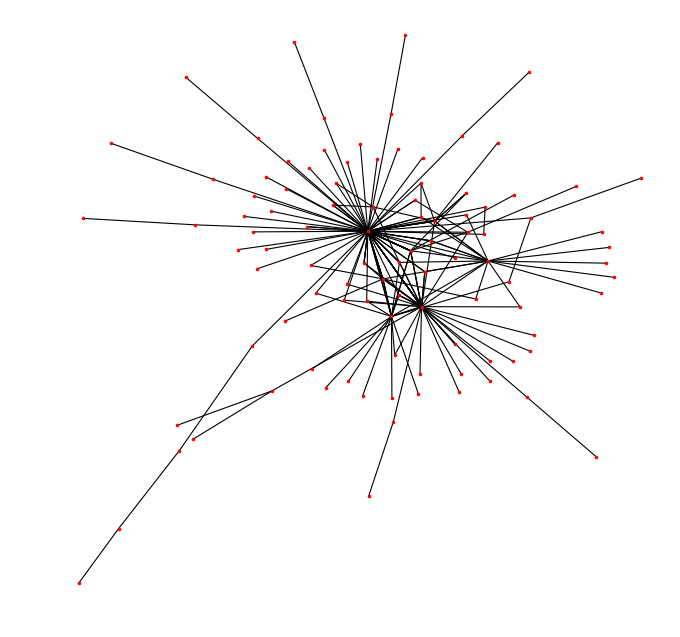

In [47]:
from matplotlib.pyplot import figure
m = 0

G = nx.scale_free_graph(100, seed=m)
G = nx.to_undirected(G)

figure(num=None, figsize=(10, 10), dpi=80, facecolor='w', edgecolor='k')
plt.axis('off')
nx.draw_networkx(G, with_labels=False, node_size=5)

### REGULAR ALGORITHM

In [49]:
cp.run('fnr.findSubgraphInstances(H, G, True)', 'profiling_tests/regular_scale_free_8_100')
p = pstats.Stats('profiling_tests/regular_scale_free_8_100')
p.strip_dirs().sort_stats('cumtime').print_stats()

Thu Jul 25 00:13:12 2019    profiling_tests/regular_scale_free_8_100

         9188565 function calls (9159574 primitive calls) in 13.040 seconds

   Ordered by: cumulative time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.000    0.000   13.040   13.040 {built-in method builtins.exec}
        1    0.002    0.002   13.040   13.040 <string>:1(<module>)
      2/1    0.001    0.001   13.039   13.039 functions_regular.py:461(findSubgraphInstances)
 9855/134    0.700    0.000   13.001    0.097 functions_regular.py:541(isomorphicExtensions)
   242003    1.526    0.000    6.784    0.000 functions_regular.py:319(findCandidates)
    12128    0.839    0.000    3.267    0.000 functions_regular.py:32(extend)
   242003    0.154    0.000    2.404    0.000 functions_regular.py:321(<listcomp>)
   371394    2.291    0.000    2.332    0.000 functions_regular.py:138(applyMap)
   630628    0.420    0.000    1.857    0.000 graph.py:434(__getitem__)
   163769    0.8

### REGULAR ALGORITHM + SUBTREE ISO

In [50]:
G = nx.scale_free_graph(100, seed=m)
G = nx.to_undirected(G)
H = parseStringToGraph('[[0,1], [1,2], [2,0], [4,2], [3,4], [5,4], [6,4], [7,4]]')

cp.run('fns.findSubgraphInstances(H, G, True)', 'profiling_tests/regular&subtree_scale_free_8_100')
p = pstats.Stats('profiling_tests/regular&subtree_scale_free_8_100')
p.strip_dirs().sort_stats('cumtime').print_stats()

Thu Jul 25 00:13:31 2019    profiling_tests/regular&subtree_scale_free_8_100

         9196871 function calls (9167349 primitive calls) in 13.509 seconds

   Ordered by: cumulative time

   ncalls  tottime  percall  cumtime  percall filename:lineno(function)
        1    0.000    0.000   13.509   13.509 {built-in method builtins.exec}
        1    0.002    0.002   13.508   13.508 <string>:1(<module>)
      2/1    0.002    0.001   13.507   13.507 functions_subtrees.py:461(findSubgraphInstances)
 9855/134    0.720    0.000   13.466    0.100 functions_subtrees.py:561(isomorphicExtensions)
   242003    1.596    0.000    7.087    0.000 functions_subtrees.py:319(findCandidates)
    12128    0.862    0.000    3.353    0.000 functions_subtrees.py:32(extend)
   242003    0.164    0.000    2.503    0.000 functions_subtrees.py:321(<listcomp>)
   371394    2.380    0.000    2.422    0.000 functions_subtrees.py:138(applyMap)
   631165    0.438    0.000    1.926    0.000 graph.py:434(__getitem__)
  

In [9]:
# input: edges of a graph written in bracketed pairs
# output: graph with corresponding edges
def parseStringToGraph(s):
    l = []

    if(s[len(s)-1] == ' '):
        s = s[:-1]

    if(s[0] == '[' and s[len(s)-1] == ']'):
        s = s[-(len(s)-1):-1]
        start = [key for key, val in enumerate(s) if val == '[']
        end = [key for key, val in enumerate(s) if val == ']']
        comma = [key for key, val in enumerate(s) if (val == ',' and not s[key-1] == ']')]

        for i in range(len(start)):
            left = [v for k, v in enumerate(s) if k in range(start[i]+1, comma[i])]
            right = [v for k, v in enumerate(s) if k in range(comma[i]+1, end[i])]

            left = int(''.join(left))
            right = int(''.join(right))
            l.append((left, right))

    H = nx.Graph()
    H.add_edges_from(l)

    return H


# reads the text file output by Josh and returns test name, hstring,
# gstring and answer in a dict
def parseFileToDict(file):
    f = open(file, 'r')
    D = {}
    index = 0
    first = True

    for line in f:
        if (line[0:4] == 'Test'):
            title = line[:-1]

        if (line[0] == '['):
            if (first):
                hstring = line[:-1]
                first = False
            else:
                gstring = line[:-1]
                first = True


        if (ord(line[0]) >= 48 and ord(line[0]) <= 57):
            ans = int(line)
            D[index] = {'title': title,
                        'hstring': hstring,
                        'gstring': gstring,
                        'answer': ans}
            index = index + 1

    return D


def test_findSubgraphInstances(file, which='regular'):

    D = parseFileToDict(file)

    for key in D.keys():
        print(D[key]['title'])
        H = nx.Graph()
        G = nx.Graph()

        hGraph = parseStringToGraph(D[key]['hstring'])
        gGraph = parseStringToGraph(D[key]['gstring'])

        H.add_edges_from(hGraph.edges())
        G.add_edges_from(gGraph.edges())

        if (which == 'regular'):
            count = fnr.findSubgraphInstances(H, G, True)

        if (which == 'subtrees'):
            count = fns.findSubgraphInstances(H, G, True)

        l = count
        ans = D[key]['answer']

        print('H: ',end='')
        print(D[key]['hstring'])
        print('G: ',end='')
        print(D[key]['gstring'])
#         print('instances: ',end='')
#         print([tuple(i.getMap()) for i in instances])
        print('correct number of instances: ',end='')
        print(ans)
        print('instances found: ',end='')
        print(l)

        if(l == ans):
            print('succeeded')
        else:
            print('failed')

        print()
